<a href="https://colab.research.google.com/github/bavinkdevadas-hub/ML-Projects/blob/main/Credit%20Scoring%20Model/Credit_Scoring_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##✅ TASK 1: Credit Scoring Model
Objective: Predict an individual's creditworthiness using past financial data.
Approach: Use classification algorithms like Logistic Regression, Decision Trees, or Random Forest.
Key Features:
● Feature engineering from financial history.
● Model accuracy assessment using metrics like Precision, Recall, F1-Score, ROC-AUC.
● Dataset could include: income, debts, payment history, etc.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset/Loan_default.csv")
df

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


In [ ]:
df.drop(["LoanID"],axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Age             255347 non-null  int64  
 1   Income          255347 non-null  int64  
 2   LoanAmount      255347 non-null  int64  
 3   CreditScore     255347 non-null  int64  
 4   MonthsEmployed  255347 non-null  int64  
 5   NumCreditLines  255347 non-null  int64  
 6   InterestRate    255347 non-null  float64
 7   LoanTerm        255347 non-null  int64  
 8   DTIRatio        255347 non-null  float64
 9   Education       255347 non-null  object 
 10  EmploymentType  255347 non-null  object 
 11  MaritalStatus   255347 non-null  object 
 12  HasMortgage     255347 non-null  object 
 13  HasDependents   255347 non-null  object 
 14  LoanPurpose     255347 non-null  object 
 15  HasCoSigner     255347 non-null  object 
 16  Default         255347 non-null  int64  
dtypes: float64

In [ ]:
df.isnull().sum()

,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0
Education,0


In [ ]:
df.duplicated().sum()

np.int64(0)

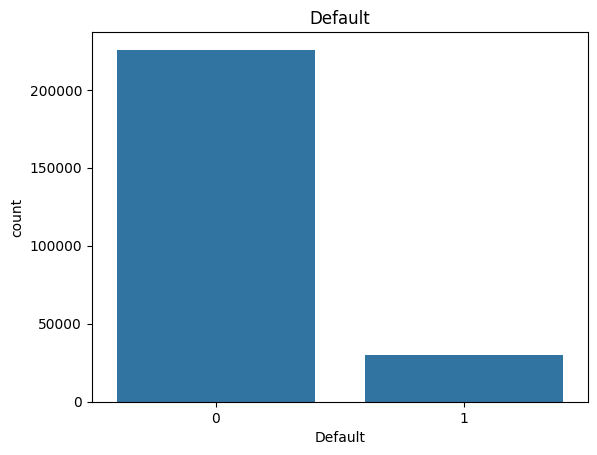

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Default', data=df)
plt.title('Default')
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['HasMortgage'] = le.fit_transform(df['HasMortgage'])
df['HasDependents'] = le.fit_transform(df['HasDependents'])
df['HasCoSigner'] = le.fit_transform(df['HasCoSigner'])
df['Education'] = le.fit_transform(df['Education'])
df['EmploymentType'] = le.fit_transform(df['EmploymentType'])
df[ 'MaritalStatus'] = le.fit_transform(df['MaritalStatus'])
df['LoanPurpose'] = le.fit_transform(df['LoanPurpose'])

In [ ]:
df

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,0,0,0,1,1,4,1,0
1,69,50432,124440,458,15,1,4.81,60,0.68,2,0,1,0,0,4,1,0
2,46,84208,129188,451,26,3,21.17,24,0.31,2,3,0,1,1,0,0,1
3,32,31713,44799,743,0,3,7.07,24,0.23,1,0,1,0,0,1,0,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,3,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,19,37979,210682,541,109,4,14.11,12,0.85,0,0,1,0,0,4,0,0
255343,32,51953,189899,511,14,2,11.55,24,0.21,1,1,0,0,0,3,0,1
255344,56,84820,208294,597,70,3,5.29,60,0.50,1,2,1,1,1,0,1,0
255345,42,85109,60575,809,40,1,20.90,48,0.44,1,1,2,1,1,4,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Age             255347 non-null  int64  
 1   Income          255347 non-null  int64  
 2   LoanAmount      255347 non-null  int64  
 3   CreditScore     255347 non-null  int64  
 4   MonthsEmployed  255347 non-null  int64  
 5   NumCreditLines  255347 non-null  int64  
 6   InterestRate    255347 non-null  float64
 7   LoanTerm        255347 non-null  int64  
 8   DTIRatio        255347 non-null  float64
 9   Education       255347 non-null  int64  
 10  EmploymentType  255347 non-null  int64  
 11  MaritalStatus   255347 non-null  int64  
 12  HasMortgage     255347 non-null  int64  
 13  HasDependents   255347 non-null  int64  
 14  LoanPurpose     255347 non-null  int64  
 15  HasCoSigner     255347 non-null  int64  
 16  Default         255347 non-null  int64  
dtypes: float64

In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# Separate features and target
x = df.drop(columns=['Default'])
y = df['Default']

# Apply SMOTE
smote = SMOTE(random_state=42)
x_res, y_res = smote.fit_resample(x, y)

# Combine into one DataFrame
df_smote = pd.DataFrame(x_res, columns=x.columns)
df_smote['Default'] = y_res
print(df_smote['Default'].value_counts())

Default
0    225694
1    225694
Name: count, dtype: int64


In [ ]:
df=df_smote

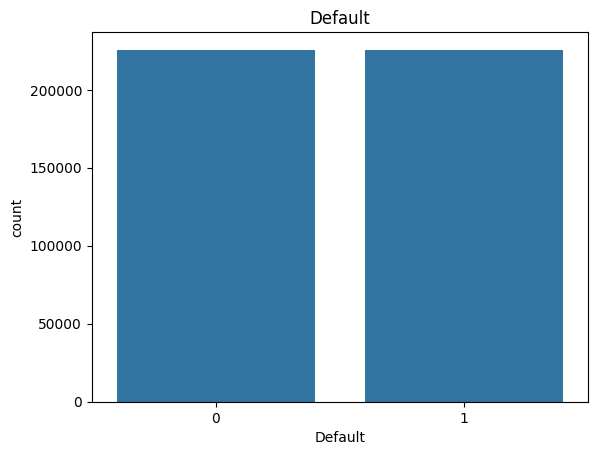

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Default', data=df)
plt.title('Default')
plt.show()

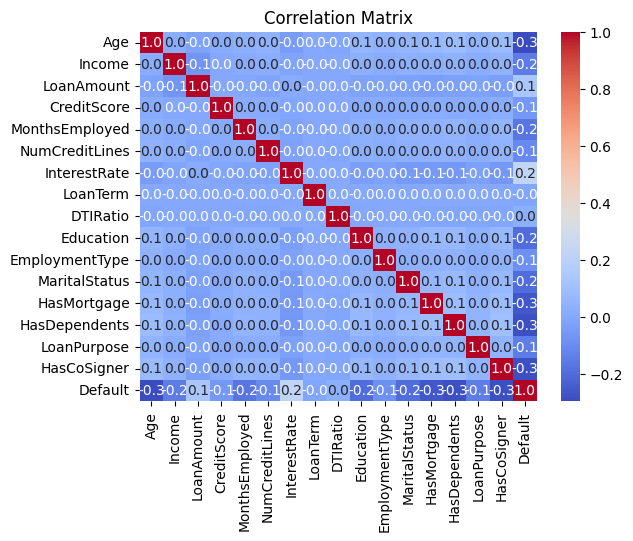

In [ ]:
# Correlation matrix
corr_matrix=df.corr()
# Heatmap of correlation matrix

sns.heatmap(corr_matrix,annot=True,fmt="0.01f",cmap="coolwarm")
plt.title("Correlation Matrix")

plt.show()

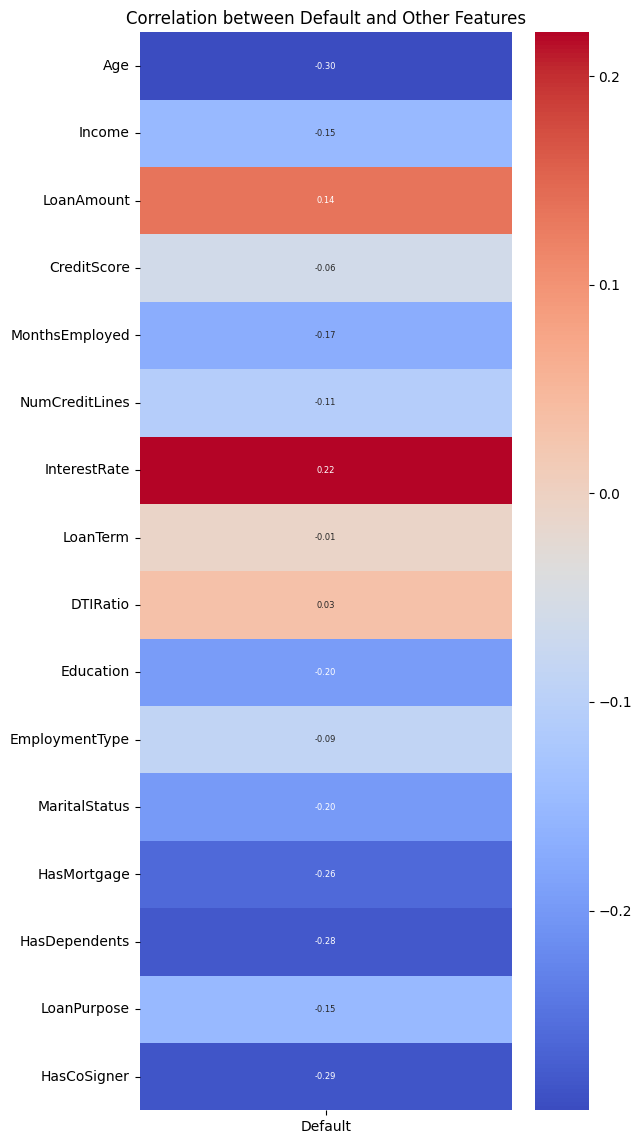

In [ ]:
# Calculate the correlation between 'Default' and all other columns
Default_corr=df.corr()['Default']
# Remove the correlation of 'Default'with itself (which is always 1)
Default_corr=Default_corr.drop('Default')
# Create a heatmap to visualize the correlations
plt.figure(figsize=(6, 14))
sns.heatmap(Default_corr.to_frame(),annot=True,fmt='.2f',cmap='coolwarm',
            cbar=True,annot_kws={'size':6}) # to_frame() converts Series to DataFrame for heatmap
plt.title('Correlation between Default and Other Features')
plt.show()

<Axes: >

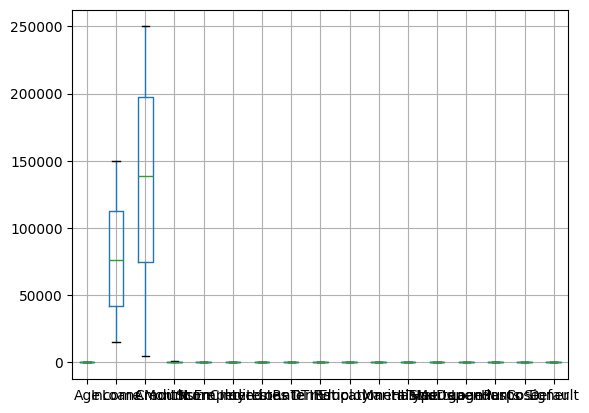

In [ ]:
df.boxplot()

In [ ]:
# Function to remove outliers using the IQR method except for one column
def remove_outliers_iqr(df,exclude_column):


  for col in df.columns:

   # Skip the specified column
    if col==exclude_column:
      continue
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    # Filter the DataFrame to remove rows with outliers in each column
    df=df[(df[col]>=lower_bound)&(df[col]<=upper_bound)]
  return df


# Specify the column to exclude
df_cleaned=remove_outliers_iqr(df,exclude_column='Default')
df=df_cleaned

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
 #Select the features that you want to scale
features = [
    'Age',
    'Income',
    'LoanAmount',
    'CreditScore',
    'MonthsEmployed',
    'NumCreditLines',
    'InterestRate',
    'LoanTerm',
    'DTIRatio',
    'Education',
    'EmploymentType',
    'MaritalStatus',
    'HasMortgage',
    'HasDependents',
    'LoanPurpose',
    'HasCoSigner'
]
# Create a MinMaxScaler object
scaler = MinMaxScaler()
# Fit the scaler to your data and transform it
scaled_data = scaler.fit_transform(df[features])
# Create a DataFrame from scaled_data with the correct column names
scaled_df=pd.DataFrame(scaled_data,columns=features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

x=scaled_df
y=df['Default']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
# Train a baseline logistic regression model
model=LogisticRegression()
model.fit(x_train,y_train)
# Predict and evaluate the model
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f"baseline model accuracy:{accuracy:.2f}")

baseline model accuracy:0.78


In [ ]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression()
#track best fold data
best_accuracy=0
best_fold=-1

# Save best fold's data
best_x_train = None
best_y_train = None
best_x_test = None
best_y_test = None
best_y_pred = None

# Loop over each fold
for fold, (train_index, test_index) in enumerate(kf.split(x), 1):
    x_train, x_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train model
    model.fit(x_train, y_train)

    # Predict
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Fold {fold} Accuracy: {acc}")

    # Update best fold
    if acc > best_accuracy:
      best_accuracy = acc
      best_fold = fold
      best_x_train = x_train
      best_y_train = y_train
      best_x_test = x_test
      best_y_test = y_test
      best_y_pred = y_pred
 # Output best fold details
print(f"\n Best Fold: {best_fold} with Accuracy: {best_accuracy}")

Fold 1 Accuracy: 0.7813863842796694
Fold 2 Accuracy: 0.7837125323999202
Fold 3 Accuracy: 0.7825273045481734
Fold 4 Accuracy: 0.7848399924676274
Fold 5 Accuracy: 0.7833335179503085

 Best Fold: 4 with Accuracy: 0.7848399924676274


In [ ]:
model = LogisticRegression()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.7848399924676274

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.8203972218837577

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.8817860584645036

In [ ]:
from xgboost import XGBClassifier
model=XGBClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.9130786357544003

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
model=AdaBoostClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.8341105707987638

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# Defining the ANN model
model = Sequential()
model.add(Dense(64, input_shape=(16,),activation='relu'))  # Hidden Layer 1
model.add(Dense(32, activation='relu'))# Hidden Layer 2
model.add(Dense(1, activation='sigmoid'))             # Output Layer

# Compiling the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 3. Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Training the model
model.fit(best_x_train, best_y_train, epochs=20, batch_size=32)

Epoch 1/20
11285/11285 ━━━━━━━━━━━━━━━━━━━━ 18s 1ms/step - accuracy: 0.8037 - loss: 0.4294
Epoch 2/20
11285/11285 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step - accuracy: 0.8171 - loss: 0.4089
Epoch 3/20
11285/11285 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step - accuracy: 0.8188 - loss: 0.4047
Epoch 4/20
11285/11285 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step - accuracy: 0.8200 - loss: 0.4028
Epoch 5/20
11285/11285 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step - accuracy: 0.8212 - loss: 0.4012
Epoch 6/20
11285/11285 ━━━━━━━━━━━━━━━━━━━━ 21s 1ms/step - accuracy: 0.8217 - loss: 0.3998
Epoch 7/20
11285/11285 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step - accuracy: 0.8241 - loss: 0.3959
Epoch 8/20
11285/11285 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step - accuracy: 0.8251 - loss: 0.3938
Epoch 9/20
11285/11285 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step - accuracy: 0.8256 - loss: 0.3925
Epoch 10/20
11285/11285 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step - accuracy: 0.8264 - loss: 0.3915
Epoch 11/20
11285/11285 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step - accuracy: 0.8269 - loss: 0.39

In [ ]:
# Evaluating the model
loss, accuracy = model.evaluate( best_x_test, best_y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

2822/2822 ━━━━━━━━━━━━━━━━━━━━ 3s 984us/step - accuracy: 0.8383 - loss: 0.3689
Model Accuracy: 83.83%


##Conclusion
This project successfully developed a Credit Scoring Model using machine learning techniques to predict the creditworthiness of loan applicants. The dataset was preprocessed by handling missing values, encoding categorical data, and scaling numerical features to improve model performance. Several machine learning and deep learning models were trained and compared. Among them, the **XGBoost classifier achieved the highest accuracy of 91.31%**, making it the best-performing model for this project. The results show that machine learning can effectively identify patterns in financial data and support accurate credit risk prediction.

In conclusion, the developed model can help financial institutions make faster and more reliable loan approval decisions while reducing the risk of loan defaults. It also demonstrates the practical use of machine learning in the banking and finance sector. In the future, the model can be improved by using larger datasets, adding more relevant features, and applying advanced optimization and explainable AI techniques to further improve its accuracy and reliability.
